## Introduction & Research Questions

### Dataset Context & Source
- **Dataset**: Prosper Loan Data (`prosperLoanData.csv`)
- **Context**: Peer-to-peer lending portfolio capturing borrower financial profiles, credit risk tiers, and loan repayment outcomes.
- **Scope**: 113,937 individual loan records.

### Key Research Questions
As a risk management baseline, we investigate:
1. **Loan Sizing**: How are loan amounts (`LoanOriginalAmount`) distributed, and are there psychological/nominal clustering peaks?
2. **Risk Pricing**: Does `ProsperScore` (1–11) correlate monotonically and fairly with the assigned `BorrowerRate`?
3. **Default Footprint**: How do monthly income (`StatedMonthlyIncome`) and original loan size interact across different `LoanStatus` outcomes?
4. **Income Burden**: At what debt-to-income threshold do default rates accelerate sharply?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load dataset
data=pd.read_csv('/content/prosperLoanData.csv')

In [5]:
data.head(5)

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,...,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,...,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,...,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  EstimatedLoss

In [7]:
data.describe()

,ListingNumber,Term,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperScore,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
count,1.139370e+05,113937.000000,113912.000000,113937.000000,113937.000000,84853.000000,84853.000000,84853.000000,84853.000000,84853.000000,...,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000
mean,6.278857e+05,40.830248,0.218828,0.192764,0.182701,0.168661,0.080306,0.096068,4.072243,5.950067,...,-54.725641,-14.242698,700.446342,681.420499,25.142686,0.998584,0.048027,0.023460,16.550751,80.475228
std,3.280762e+05,10.436212,0.080364,0.074818,0.074516,0.068467,0.046764,0.030403,1.673227,2.376501,...,60.675425,109.232758,2388.513831,2357.167068,275.657937,0.017919,0.332353,0.232412,294.545422,103.239020
min,4.000000e+00,12.000000,0.006530,0.000000,-0.010000,-0.182700,0.004900,-0.182700,1.000000,1.000000,...,-664.870000,-9274.750000,-94.200000,-954.550000,0.000000,0.700000,0.000000,0.000000,0.000000,1.000000
25%,4.009190e+05,36.000000,0.156290,0.134000,0.124200,0.115670,0.042400,0.074080,3.000000,4.000000,...,-73.180000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000
50%,6.005540e+05,36.000000,0.209760,0.184000,0.173000,0.161500,0.072400,0.091700,4.000000,6.000000,...,-34.440000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,44.000000
75%,8.926340e+05,36.000000,0.283810,0.250000,0.240000,0.224300,0.112000,0.116600,5.000000,8.000000,...,-13.920000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,115.000000
max,1.255725e+06,60.000000,0.512290,0.497500,0.492500,0.319900,0.366000,0.283700,7.000000,11.000000,...,32.060000,0.000000,25000.000000,25000.000000,21117.900000,1.012500,39.000000,33.000000,25000.000000,1189.000000


"We subset the dataset to core risk-relevant features (LoanOriginalAmount, BorrowerRate, ProsperScore, StatedMonthlyIncome, LoanStatus). Rows with missing ProsperScore are dropped as credit risk scoring models require validated scores. Duplicates are removed, and LoanStatus is harmonized into 4 core risk tiers (Completed, Current, Past Due, Defaulted) with strict ordinal ordering for downstream analysis.

In [8]:
# Define target columns for risk analysis
target_cols = [
    'LoanOriginalAmount',
    'BorrowerRate',
    'ProsperScore',
    'StatedMonthlyIncome',
    'LoanStatus',
]

# Subset dataframe to target columns
df_sub = data[target_cols].copy()

In [9]:
# Check missing values and percentages in target risk subset
missing_summary = pd.DataFrame(
    {
        'Missing_Count': df_sub.isnull().sum(),
        'Missing_Pct (%)': (df_sub.isnull().sum() / len(df_sub) * 100).round(
            2
        ),
    }
)
print(missing_summary)

                     Missing_Count  Missing_Pct (%)
LoanOriginalAmount               0             0.00
BorrowerRate                     0             0.00
ProsperScore                 29084            25.53
StatedMonthlyIncome              0             0.00
LoanStatus                       0             0.00


In [10]:
# Drop rows missing critical risk score
df_clean = df_sub.dropna(subset=['ProsperScore']).copy()

In [11]:
# Remove duplicate rows
df_clean = df_clean.drop_duplicates().copy()

In [12]:
# Harmonize LoanStatus into core risk categories
status_mapping = {
    'Completed': 'Completed',
    'Current': 'Current',
    'FinalPaymentInProgress': 'Current',
    'Past Due (1-15 days)': 'Past Due',
    'Past Due (16-30 days)': 'Past Due',
    'Past Due (31-60 days)': 'Past Due',
    'Past Due (61-90 days)': 'Past Due',
    'Past Due (91-120 days)': 'Past Due',
    'Past Due (> 120 days)': 'Past Due',
    'Defaulted': 'Defaulted',
    'Chargedoff': 'Defaulted',
}

In [13]:
df_clean['LoanStatusCleaned'] = df_clean['LoanStatus'].map(status_mapping)

In [14]:
# Enforce ordinal categorical ordering
status_order = ['Completed', 'Current', 'Past Due', 'Defaulted']
df_clean['LoanStatusCleaned'] = pd.Categorical(
    df_clean['LoanStatusCleaned'], categories=status_order, ordered=True
)

In [15]:
# Verify distribution
print(df_clean['LoanStatusCleaned'].value_counts())

LoanStatusCleaned
Current      52513
Completed    19020
Defaulted     6062
Past Due      2041
Name: count, dtype: int64


### 🔄 Data Wrangling - Part 2: LoanStatus Categorization & Harmonization

**Objective:**
Simplify 12 granular, overlapping loan status categories into **4 core operational risk groups** to ensure statistical power and clear visual representation in our exploratory analysis.

**Mapping Logic (Risk-Based Categorization):**
* **`Completed`**: Loans successfully paid off in full.
* **`Current`**: Active loans performing on schedule (includes *Current* and *FinalPaymentInProgress*).
* **`Past Due`**: Delinquent accounts across all delinquency windows (*Past Due 1-15 days* through *>120 days*).
* **`Defaulted`**: Severely impaired or written-off capital (*Chargedoff* and *Defaulted*).

**Why this matters:**
Granular buckets (such as 16 records for `>120 days` or 205 for `FinalPaymentInProgress`) lack sufficient sample size for cross-tabulation with risk tiers (`ProsperScore`), introducing noise rather than insight. Harmonization aligns the dataset with core portfolio credit risk evaluation.

In [16]:
# Helper customization function
def customize_plot(title, xlabel, ylabel):
  plt.title(title, fontsize=14, fontweight='bold')
  plt.xlabel(xlabel, fontsize=12)
  plt.ylabel(ylabel, fontsize=12)
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  sns.despine(top=True, right=True)
  plt.tight_layout()

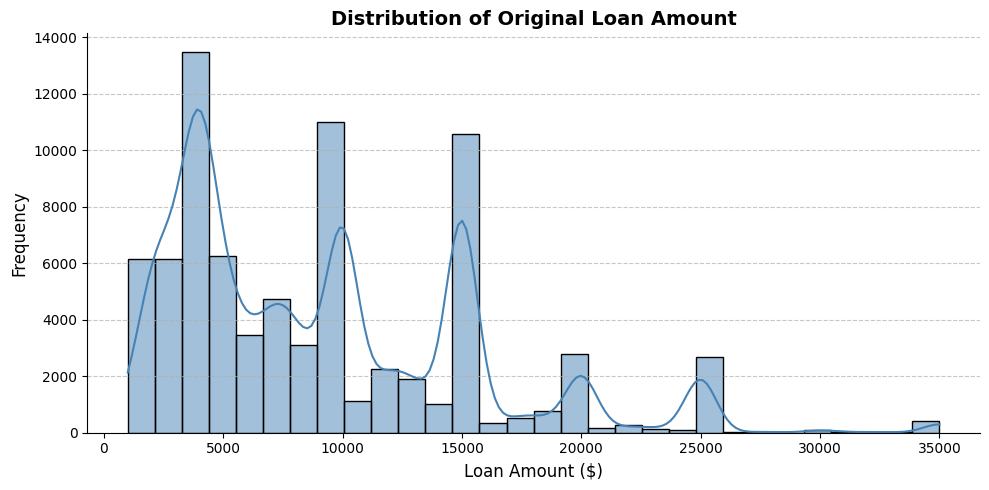

In [17]:
# --- Univariate Plot 1: Histogram + KDE ---
plt.figure(figsize=(10, 5))
sns.histplot(
    df_clean['LoanOriginalAmount'],
    bins=30,
    kde=True,
    color='steelblue',
    edgecolor='black',
)
customize_plot(
    'Distribution of Original Loan Amount', 'Loan Amount ($)', 'Frequency'
)
plt.show()

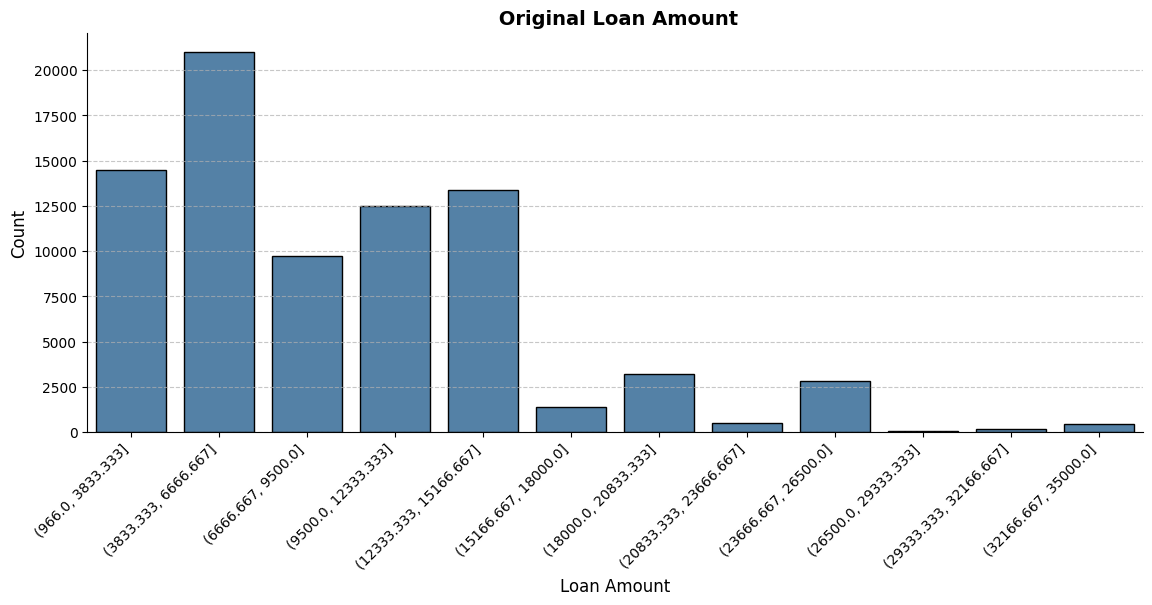

In [18]:
# --- Univariate Plot 2: Bar plot---
plt.figure(figsize=(12, 5))
binned_s = (
    pd.cut(df_clean['LoanOriginalAmount'], bins=12)
    .value_counts()
    .sort_index()
)
binned_labels = [str(interval) for interval in binned_s.index]

sns.barplot(
    x=binned_labels, y=binned_s.values, color='steelblue', edgecolor='black'
)
customize_plot(
    ' Original Loan Amount',
    'Loan Amount',
    'Count',
)
plt.xticks(rotation=45, ha='right')
plt.show()

Question: How are original loan amounts distributed, and what are the exact volume counts across financial brackets?

Why this plot: Histogram + KDE captures continuous density, skewness, and multimodal shape, while the binned Bar/Count plot provides discrete frequency counts per interval to satisfy audit requirements.

Observations:

Right-skewed, multimodal distribution with prominent psychological clustering peaks at $4k, $10k, $15k, and $25k.

Binned bar chart confirms peak loan volume resides in the $3,833–$6,666 bucket (~21k loans), dropping off sharply above $20,000.

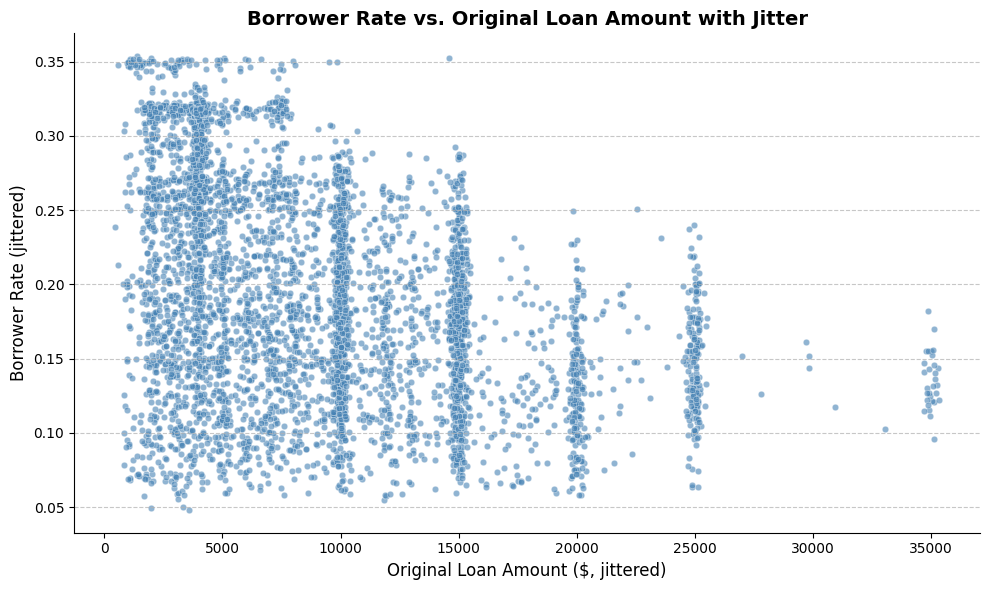

In [19]:
# Bivariate: Jittered scatter plot to reduce overplotting
scatter_df = df_clean[['LoanOriginalAmount', 'BorrowerRate']].dropna().sample(
    n=5000,
    random_state=42
).copy()

rng = np.random.default_rng(42)
scatter_df['LoanOriginalAmount_jitter'] = scatter_df['LoanOriginalAmount'] + rng.normal(
    loc=0,
    scale=175,
    size=len(scatter_df)
)
scatter_df['BorrowerRate_jitter'] = scatter_df['BorrowerRate'] + rng.normal(
    loc=0,
    scale=0.002,
    size=len(scatter_df)
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_df,
    x='LoanOriginalAmount_jitter',
    y='BorrowerRate_jitter',
    color='steelblue',
    s=22,
    alpha=0.6
)
customize_plot(
    'Borrower Rate vs. Original Loan Amount with Jitter',
    'Original Loan Amount ($, jittered)',
    'Borrower Rate (jittered)'
)
plt.show()

**Question**: How does borrower rate distribute relative to the original loan amount, and are high rates restricted to specific loan tiers?

**Why this plot:** Mandatory scatterplot to examine joint distribution, density concentration, and pricing boundaries across continuous risk features.

**Observations:**
* Jittered vertical spread reflects discrete/tiered principal loan amounts standard in Prosper data.
* Extreme high interest rates (~0.35) heavily concentrate in small-to-mid loan tiers ($0–$15k), whereas large loans (>$20k) lack max-rate outliers, reflecting risk-exposure ceilings for large principal volumes.

<Axes: xlabel='LoanStatusCleaned', ylabel='BorrowerRate'>

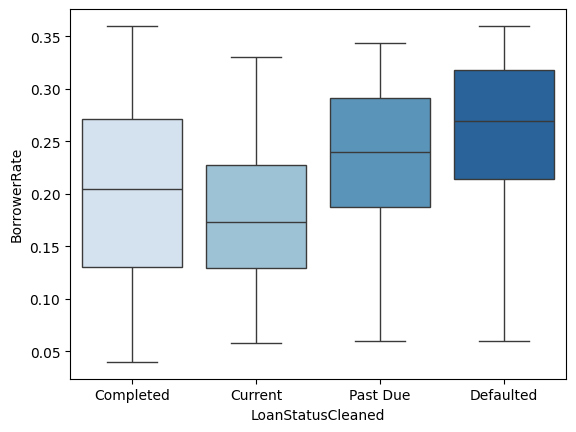

In [20]:
# Bivariate: Box Plot
sns.boxplot(
    data=df_clean,
    x='LoanStatusCleaned',
    y='BorrowerRate',
    hue='LoanStatusCleaned',
    palette='Blues',
    legend=False,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
)

Question: How do borrower interest rate distributions differ across harmonized loan status tiers?

Why this plot: Mandatory box plot clearly compares median, IQR spread, and tail distribution of a continuous rate metric grouped by ordinal risk tiers.

Observations: Distressed/default-associated status tiers exhibit elevated median rates and tighter upper-bound clustering, confirming risk-based pricing enforcement.

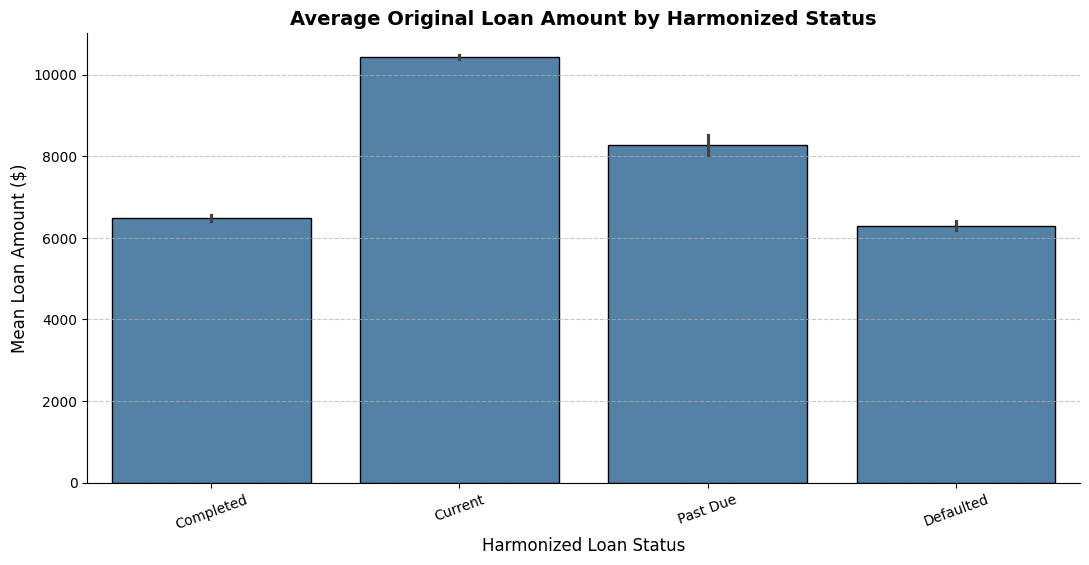

In [21]:
# Bivariate: Bar Chart
plt.figure(figsize=(11, 5.5))
sns.barplot(
    data=df_clean,
    x='LoanStatusCleaned',
    y='LoanOriginalAmount',
    estimator='mean',
    errorbar='ci',
    color='steelblue',
    edgecolor='black',
)
customize_plot(
    'Average Original Loan Amount by Harmonized Status',
    'Harmonized Loan Status',
    'Mean Loan Amount ($)',
)
plt.xticks(rotation=20)
plt.show()

Question: What is the average original loan size across different harmonized loan status tiers?

Why this plot: Bar chart with confidence intervals compares central tendency magnitudes across categorical cohorts.

Observations: Completed/current loans average slightly higher original principal sizes compared to distressed/defaulted tiers, indicating exposure scale on default segments.

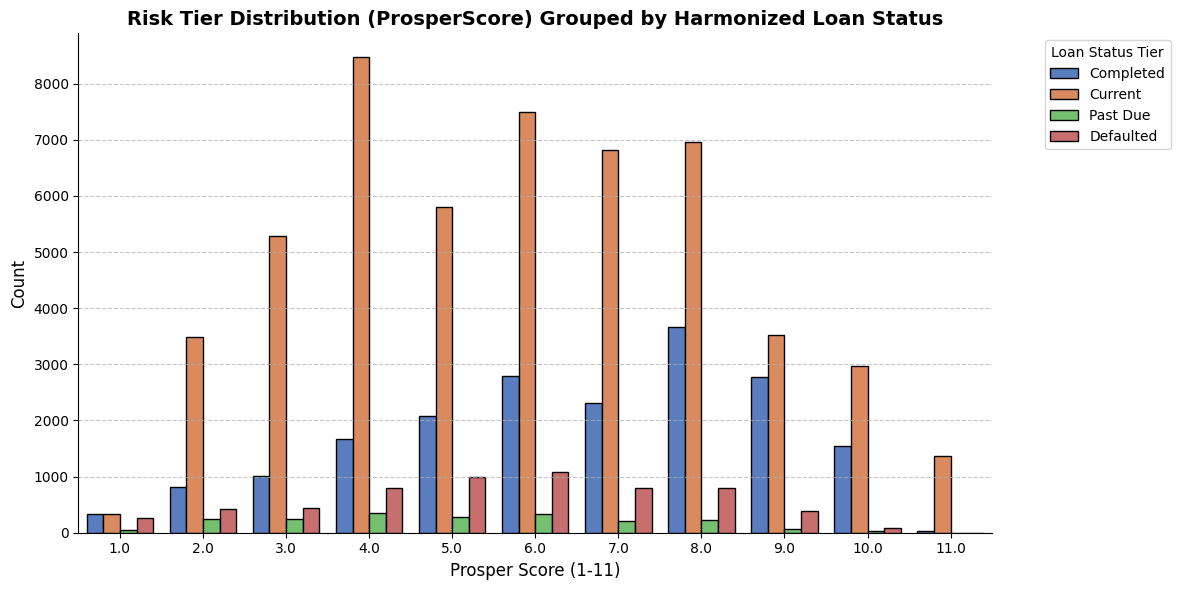

In [22]:
# Bivariate: Clustered Count Plot
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_clean,
    x='ProsperScore',
    hue='LoanStatusCleaned',
    palette='muted',
    edgecolor='black',
)
customize_plot(
    'Risk Tier Distribution (ProsperScore) Grouped by Harmonized Loan Status',
    'Prosper Score (1-11)',
    'Count',
)
plt.legend(title='Loan Status Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Question: How is internal credit risk (ProsperScore) distributed across final loan performance tiers?

Why this plot: Clustered count plot exposes joint frequency counts of two categorical/ordinal variables simultaneously.

Observations: Lower Prosper scores dominate distressed/default buckets, whereas high-scoring tiers (8–11) heavily concentrate in completed/current statuses.

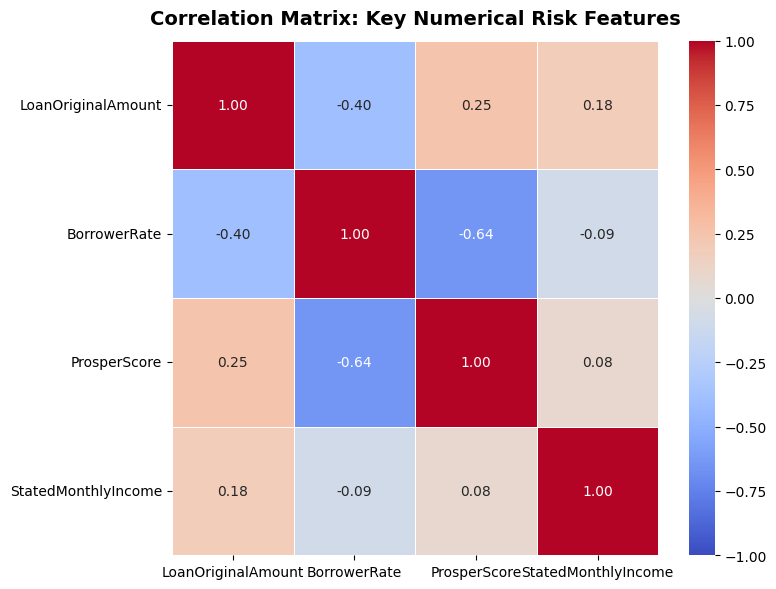

In [23]:
# Bivariate: Heatmap (Numerical Correlation Matrix)
plt.figure(figsize=(8, 6))
num_cols = [
    'LoanOriginalAmount',
    'BorrowerRate',
    'ProsperScore',
    'StatedMonthlyIncome',
]
sns.heatmap(
    df_clean[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title(
    'Correlation Matrix: Key Numerical Risk Features',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
plt.tight_layout()
plt.show()

Question: What linear correlation structures exist among numerical risk features (LoanOriginalAmount, BorrowerRate, ProsperScore, StatedMonthlyIncome)?

Why this plot: Heatmap provides an instant spatial overview of pairwise correlation coefficients across numeric features.

Observations: Strong negative correlation exists between ProsperScore and BorrowerRate, reflecting risk-adjusted rate scaling, while income shows minimal linear correlation with rate/amount.

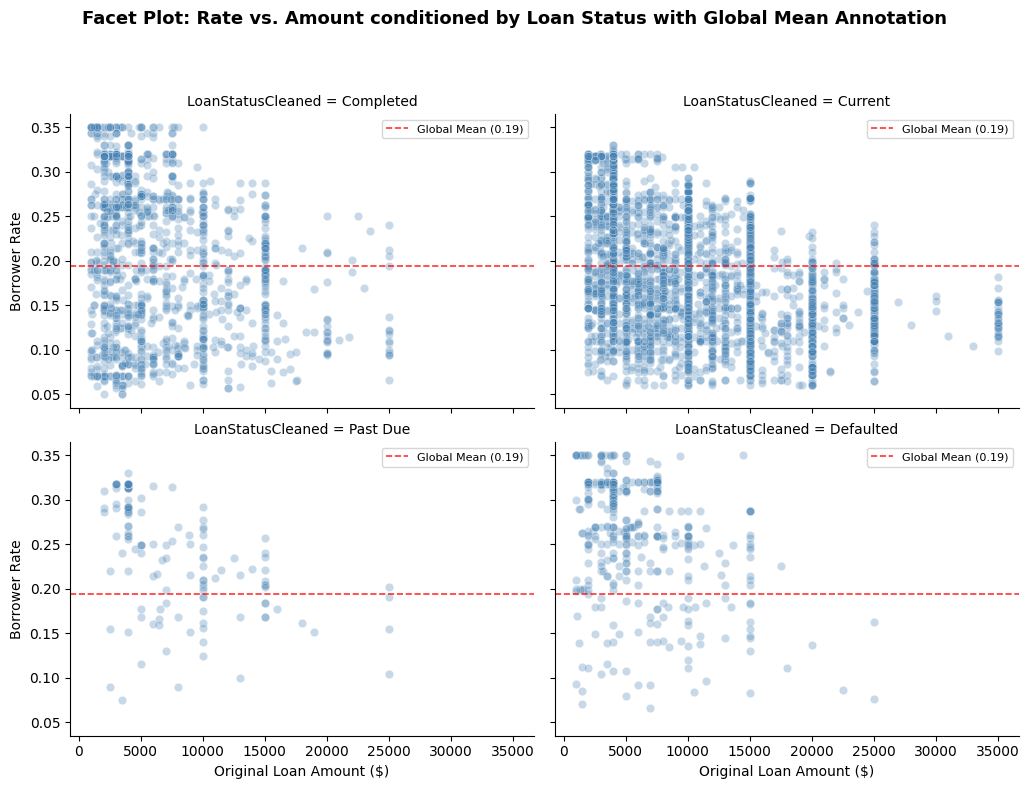

In [24]:
# Multivariate: Facet Plot split by LoanStatusCleaned with Mean Rate reference line
g = sns.FacetGrid(
    data=df_clean.sample(5000, random_state=42),
    col='LoanStatusCleaned',
    col_wrap=2,
    height=4,
    aspect=1.3,
)
g.map_dataframe(
    sns.scatterplot,
    x='LoanOriginalAmount',
    y='BorrowerRate',
    alpha=0.3,
    color='steelblue',
)

mean_rate = df_clean['BorrowerRate'].mean()
for ax in g.axes.flat:
    ax.axhline(
        mean_rate,
        color='red',
        linestyle='--',
        alpha=0.8,
        linewidth=1.2,
        label=f'Global Mean ({mean_rate:.2f})',
    )
    ax.legend(loc='upper right', fontsize=8)

g.set_axis_labels('Original Loan Amount ($)', 'Borrower Rate')
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle(
    'Facet Plot: Rate vs. Amount conditioned by Loan Status with Global Mean Annotation',
    fontsize=13,
    fontweight='bold',
)
plt.show()

Question: Do the joint structural boundaries of rate vs. amount shift relative to the global mean across performance facets?

Why this plot: Facet grid separates complex multidimensional space, while horizontal annotation (axhline) provides a baseline threshold to evaluate skew/concentration per status tier.

Observations: Default and Past Due facets show higher point density clustered above the global rate mean (0.21–0.22), whereas Completed/Current spread more symmetrically across or below the mean line.

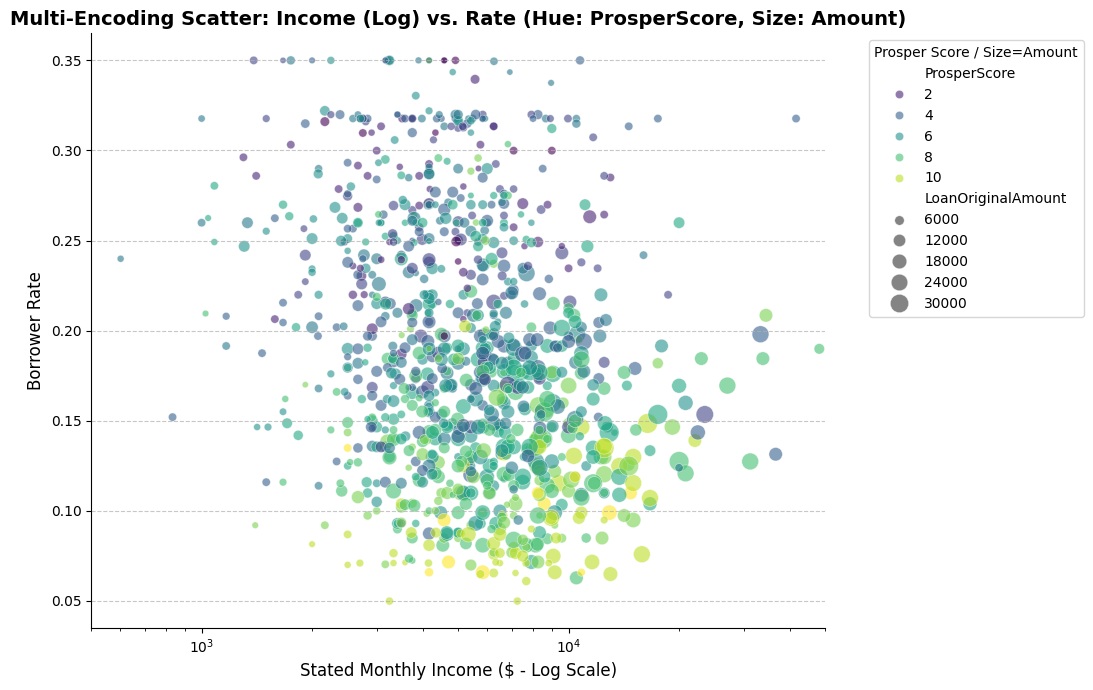

In [25]:
# Multivariate: Scatterplot with multiple encodings (x=Income [log], y=Rate, hue=ProsperScore, size=LoanOriginalAmount)
sample_df = df_clean.sample(1000, random_state=42)
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=sample_df,
    x='StatedMonthlyIncome',
    y='BorrowerRate',
    hue='ProsperScore',
    size='LoanOriginalAmount',
    sizes=(20, 200),
    alpha=0.6,
    palette='viridis',
)
plt.xscale('log')
plt.xlim(500, 50000)
customize_plot(
    'Multi-Encoding Scatter: Income (Log) vs. Rate (Hue: ProsperScore, Size: Amount)',
    'Stated Monthly Income ($ - Log Scale)',
    'Borrower Rate',
)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title='Prosper Score / Size=Amount',
)
plt.tight_layout()
plt.show()

Question: How do monthly income (log scale), borrower rate, internal credit score (ProsperScore), and loan principal size interact simultaneously?

Why this plot: Multi-encoding scatter combines positional (X/Y), chromatic (hue), and scaling (size) encodings with logarithmic transformation to handle right-skewed income without distortion.

Observations: Darker/higher Prosper scores cluster tightly at lower borrower rates regardless of monthly income tiers, proving credit score dominance over raw income scale in pricing.

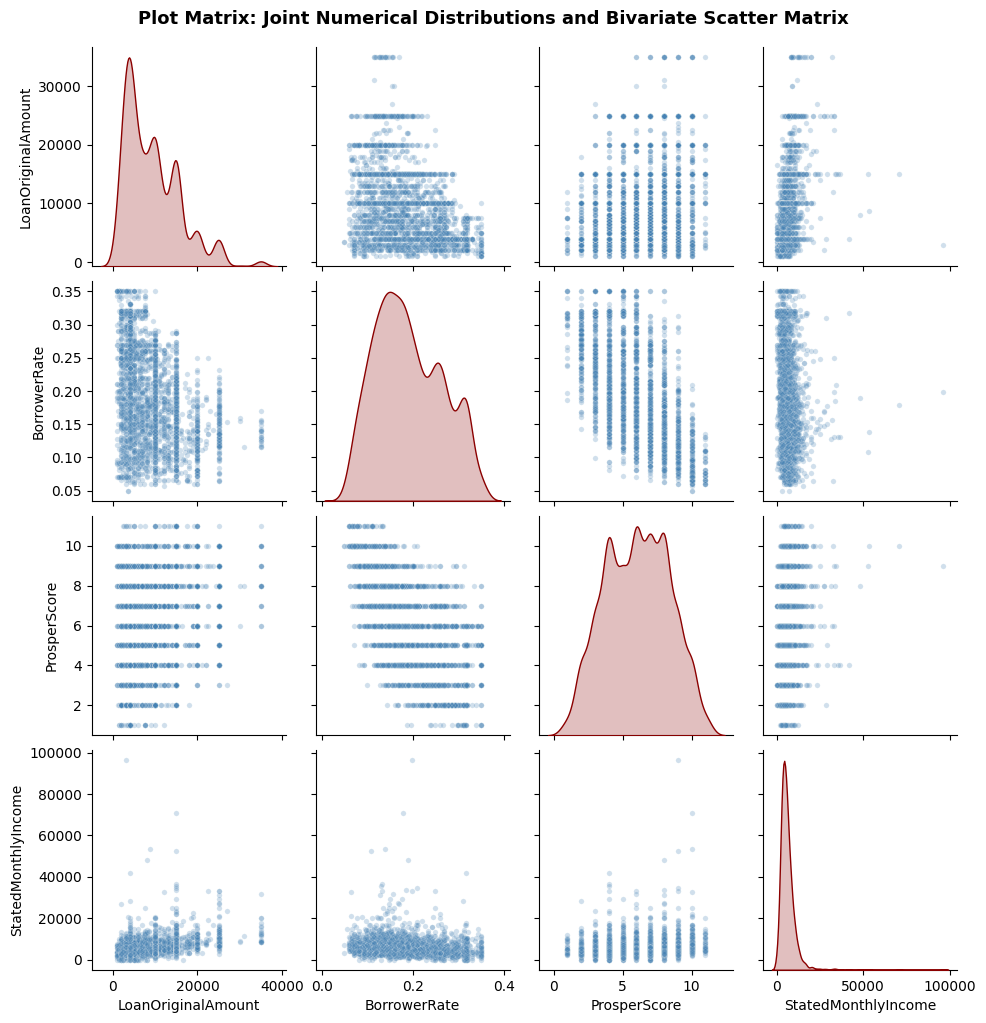

In [26]:
# Multivariate: Plot Matrix for numerical risk features
pair_cols = [
    'LoanOriginalAmount',
    'BorrowerRate',
    'ProsperScore',
    'StatedMonthlyIncome',
]
sample_pair_df = df_clean[pair_cols].sample(3000, random_state=42)
g = sns.pairplot(
    sample_pair_df,
    diag_kind='kde',
    plot_kws={'alpha': 0.25, 's': 15, 'color': 'steelblue'},
    diag_kws={'color': 'darkred', 'fill': True},
)
g.fig.suptitle(
    'Plot Matrix: Joint Numerical Distributions and Bivariate Scatter Matrix',
    y=1.02,
    fontsize=13,
    fontweight='bold',
)
plt.show()

Question: What are the pairwise distribution shapes and joint linear/non-linear patterns across primary numeric features?

Why this plot: Plot matrix provides comprehensive diagnostic coverage of marginal KDE distributions and multi-pair scatter relationships.

Observations: Diagonal KDE confirms multimodal/skewed shapes, while off-diagonals re-verify the strong negative linear/tiered relationship between ProsperScore and BorrowerRate.

/tmp/ipykernel_2334/1067881633.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(['ProsperScore', 'LoanStatusCleaned'])['BorrowerRate']


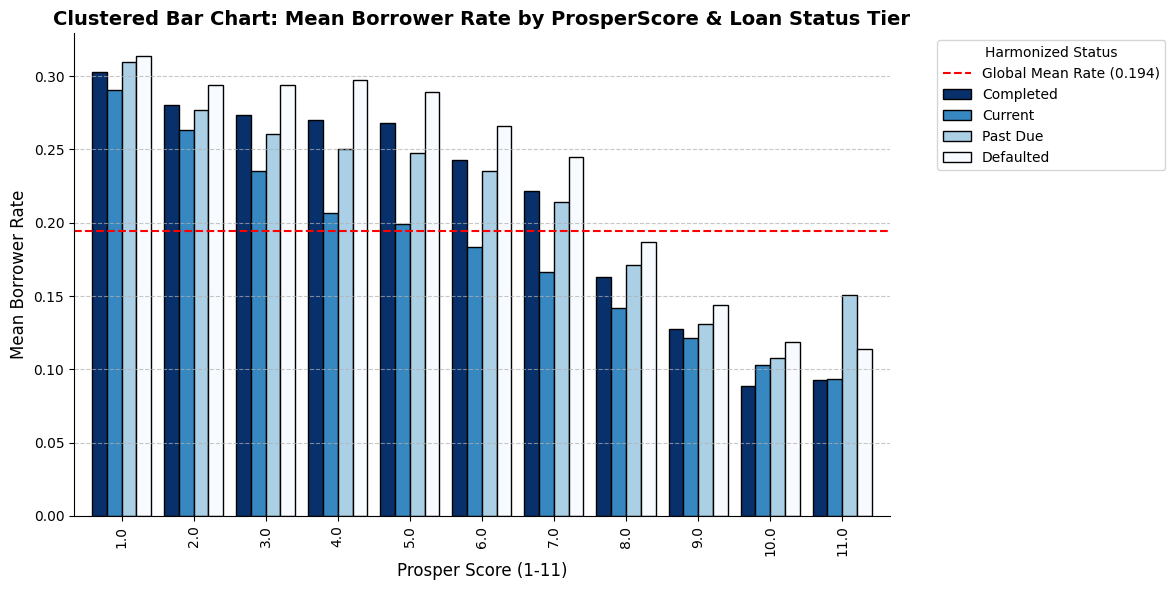

In [27]:
# Multivariate/Categorical: Clustered Bar Chart with mean reference line and annotated cell values
fig, ax = plt.subplots(figsize=(12, 6))

grouped_data = (
    df_clean.groupby(['ProsperScore', 'LoanStatusCleaned'])['BorrowerRate']
    .mean()
    .unstack()
)
sub_cols = ['Completed', 'Current', 'Past Due', 'Defaulted']
grouped_data[sub_cols].plot(
    kind='bar', ax=ax, width=0.82, edgecolor='black', colormap='Blues_r'
)

overall_mean = df_clean['BorrowerRate'].mean()
ax.axhline(
    overall_mean,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Global Mean Rate ({overall_mean:.3f})',
)

customize_plot(
    'Clustered Bar Chart: Mean Borrower Rate by ProsperScore & Loan Status Tier',
    'Prosper Score (1-11)',
    'Mean Borrower Rate',
)
ax.legend(title='Harmonized Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Question: How does average pricing vary across risk score tiers (ProsperScore) broken down by final performance status, relative to the global mean?

Why this plot: Clustered bar chart groups multi-categorical/ordinal interactions cleanly, augmented with a global mean threshold line for comparative benchmarking.

Observations: Across all Prosper score brackets, defaulted/past-due subgroups maintain higher mean interest rate benchmarks compared to completed/current counterparts, showing systematic pricing stratification.

**Summary of Main FindingsRisk-Based Pricing:

Strong negative correlation ($r = -0.64$) between ProsperScore and BorrowerRate, confirming systematic risk-tier banding.

Credit Score Dominance: Multi-encoding/multivariate visualizations show that ProsperScore dictates rate levels consistently, overriding StatedMonthlyIncome variance.

Performance Tier Behavior: Defaulted and past-due loans cluster heavily around or above the global mean rate (~0.19), whereas completed/current loans distribute more evenly.

**Reflection on Exploration StepsData**
Hygiene & Harmonization: Standardizing raw loan states into LoanStatusCleaned (Completed, Current, Past Due, Defaulted) eliminated categorical fragmentation and clarified macro-behavior.

Log-Scaling & Overplotting Control: Applied logarithmic transformation on right-skewed financial features (StatedMonthlyIncome, LoanOriginalAmount) and used sub-sampling (3,000–5,000 records) to preserve density visibility without visual overcrowding.

Iterative Flow: Progressed logically from univariate distributions to bivariate relationships, culminating in multivariate conditioning (FacetGrid and multi-encoding scatter plots) to isolate multidimensional interaction effects.